# Maze2D exploration with Minari

This notebook replaces the old MAESTD-style exploration with a Minari-first workflow.

It does three things:
1. inspects the raw local `maze2d-medium.hdf5` file exactly as it is stored,
2. reconstructs episode boundaries from the raw D4RL-style arrays,
3. materializes a local Minari dataset so the same data can be explored episode-by-episode.

The emphasis here is not just loading the dataset, but documenting **what the dataset actually looks like**, how the arrays line up, and where the structure is a little surprising.

In [61]:
import json
import os
from pathlib import Path

import gymnasium as gym
import h5py
import matplotlib.pyplot as plt
import minari
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from minari.data_collector.episode_buffer import EpisodeBuffer

PROJECT_ROOT = Path.cwd()
RAW_DATASET_PATH = PROJECT_ROOT / "maze2d-medium.hdf5"
LAYOUT_DATA_PATH = PROJECT_ROOT / "maze_layouts" / "maze2d_layouts.json"
MINARI_ROOT = PROJECT_ROOT / ".minari"
os.environ["MINARI_DATASETS_PATH"] = str(MINARI_ROOT / "datasets")

MINARI_DATASET_ID = "analysis/maze2d/medium-raw-v0"
FORCE_REBUILD_MINARI = False
INCLUDE_INCOMPLETE_TAIL = False

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

assert RAW_DATASET_PATH.exists(), f"Missing dataset file: {RAW_DATASET_PATH}"
assert LAYOUT_DATA_PATH.exists(), f"Missing layout dataset: {LAYOUT_DATA_PATH}"
MINARI_ROOT.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw dataset: {RAW_DATASET_PATH}")
print(f"Layout dataset: {LAYOUT_DATA_PATH}")
print(f"Minari datasets root: {os.environ['MINARI_DATASETS_PATH']}")
print(f"Minari version: {minari.__version__}")

Project root: c:\4th year\project
Raw dataset: c:\4th year\project\maze2d-medium.hdf5
Layout dataset: c:\4th year\project\maze_layouts\maze2d_layouts.json
Minari datasets root: c:\4th year\project\.minari\datasets
Minari version: 0.5.3


In [62]:
def walk_hdf5(handle):
    rows = []

    def visitor(name, obj):
        row = {
            "name": name,
            "kind": "group" if isinstance(obj, h5py.Group) else "dataset",
        }
        if isinstance(obj, h5py.Dataset):
            row["shape"] = obj.shape
            row["dtype"] = str(obj.dtype)
        else:
            row["shape"] = "-"
            row["dtype"] = "-"
        rows.append(row)

    handle.visititems(visitor)
    return pd.DataFrame(rows)


def load_raw_arrays(dataset_path):
    with h5py.File(dataset_path, "r") as f:
        raw = {
            "observations": f["observations"][:],
            "actions": f["actions"][:],
            "rewards": f["rewards"][:],
            "terminals": f["terminals"][:],
            "timeouts": f["timeouts"][:],
            "goals": f["infos/goal"][:],
            "qpos": f["infos/qpos"][:],
            "qvel": f["infos/qvel"][:],
        }
    return raw


def build_episode_index(raw):
    done = raw["terminals"] | raw["timeouts"]
    ends = np.flatnonzero(done)
    starts = np.concatenate(([0], ends[:-1] + 1)) if len(ends) else np.array([], dtype=np.int64)
    rows = []

    for episode_id, (start, end) in enumerate(zip(starts, ends)):
        rows.append(
            {
                "episode_id": episode_id,
                "start_idx": int(start),
                "end_idx": int(end),
                "length": int(end - start + 1),
                "terminated": bool(raw["terminals"][end]),
                "truncated": bool(raw["timeouts"][end]),
                "return": float(raw["rewards"][start : end + 1].sum()),
                "goal_x": float(raw["goals"][start, 0]),
                "goal_y": float(raw["goals"][start, 1]),
            }
        )

    tail_start = int(ends[-1] + 1) if len(ends) else 0
    tail_length = int(len(done) - tail_start)
    return pd.DataFrame(rows), tail_start, tail_length


def summarize_array(name, array, preview_rows=20000):
    preview = array[:preview_rows]
    row = {
        "name": name,
        "shape": array.shape,
        "dtype": str(array.dtype),
    }
    if preview.ndim == 1:
        row["preview_min"] = float(preview.min())
        row["preview_max"] = float(preview.max())
        row["preview_mean"] = float(preview.mean())
    else:
        row["preview_min"] = np.asarray(preview.min(axis=0)).round(6).tolist()
        row["preview_max"] = np.asarray(preview.max(axis=0)).round(6).tolist()
        row["preview_mean"] = np.asarray(preview.mean(axis=0)).round(6).tolist()
    return row


def inspect_boundary(raw, boundary_idx, radius=2):
    idx = list(range(max(0, boundary_idx - radius), min(len(raw["rewards"]), boundary_idx + radius + 1)))
    return pd.DataFrame(
        {
            "idx": idx,
            "obs_x": raw["observations"][idx, 0],
            "obs_y": raw["observations"][idx, 1],
            "obs_vx": raw["observations"][idx, 2],
            "obs_vy": raw["observations"][idx, 3],
            "act_x": raw["actions"][idx, 0],
            "act_y": raw["actions"][idx, 1],
            "reward": raw["rewards"][idx],
            "terminal": raw["terminals"][idx],
            "timeout": raw["timeouts"][idx],
            "goal_x": raw["goals"][idx, 0],
            "goal_y": raw["goals"][idx, 1],
        }
    )


def build_episode_buffers(raw, include_incomplete_tail=False):
    episode_index_df, tail_start, tail_length = build_episode_index(raw)
    buffers = []

    for row in episode_index_df.itertuples(index=False):
        start = row.start_idx
        end = row.end_idx
        buffers.append(
            EpisodeBuffer(
                id=int(row.episode_id),
                observations=raw["observations"][start : end + 1],
                actions=raw["actions"][start : end + 1],
                rewards=raw["rewards"][start : end + 1].astype(np.float32),
                terminations=raw["terminals"][start : end + 1],
                truncations=raw["timeouts"][start : end + 1],
                infos={
                    "goal": raw["goals"][start : end + 1],
                    "qpos": raw["qpos"][start : end + 1],
                    "qvel": raw["qvel"][start : end + 1],
                    "raw_index": np.arange(start, end + 1, dtype=np.int64),
                },
            )
        )

    if include_incomplete_tail and tail_length > 0:
        start = tail_start
        end = len(raw["rewards"]) - 1
        truncations = np.zeros(tail_length, dtype=bool)
        truncations[-1] = True
        buffers.append(
            EpisodeBuffer(
                id=len(buffers),
                observations=raw["observations"][start : end + 1],
                actions=raw["actions"][start : end + 1],
                rewards=raw["rewards"][start : end + 1].astype(np.float32),
                terminations=np.zeros(tail_length, dtype=bool),
                truncations=truncations,
                infos={
                    "goal": raw["goals"][start : end + 1],
                    "qpos": raw["qpos"][start : end + 1],
                    "qvel": raw["qvel"][start : end + 1],
                    "raw_index": np.arange(start, end + 1, dtype=np.int64),
                },
            )
        )

    return buffers


def ensure_minari_dataset(raw, dataset_id, force_rebuild=False, include_incomplete_tail=False):
    local_datasets = minari.list_local_datasets(prefix="analysis/maze2d")

    if dataset_id in local_datasets:
        if force_rebuild:
            raise RuntimeError(
                f"{dataset_id} already exists locally. Choose a new dataset id or delete it manually before rebuilding."
            )
        return minari.load_dataset(dataset_id)

    buffers = build_episode_buffers(raw, include_incomplete_tail=include_incomplete_tail)
    return minari.create_dataset_from_buffers(
        dataset_id=dataset_id,
        buffer=buffers,
        observation_space=gym.spaces.Box(low=-np.inf, high=np.inf, shape=(4,), dtype=np.float32),
        action_space=gym.spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32),
        description=(
            "Local Minari view of maze2d-medium.hdf5 created for structural analysis. "
            "Observations are stored transition-aligned because the raw file does not expose an explicit final next-observation per episode."
        ),
        algorithm_name="unknown / imported from local D4RL-style HDF5",
        author="local analysis notebook",
        author_email="not-specified",
        code_permalink="local-notebook",
    )


def load_layout_records(layout_data_path):
    payload = json.loads(layout_data_path.read_text(encoding="utf-8"))
    return payload["mazes"]


def maze_occupancy_in_sim_frame(record):
    """Map the extracted row/col grid into the Maze2D simulator x/y frame."""
    occupancy = np.array(record["occupancy_grid"])
    return np.flipud(occupancy.T)


def cells_to_sim_points(cells, record):
    """Convert [row, col] cells into simulator-style (x, y) coordinates."""
    n_cols = record["width"]
    points = []
    for row, col in cells:
        points.append((float(row), float(n_cols - 1 - col)))
    return points

## 1. Raw HDF5 structure

The original file is a **flat, step-aligned D4RL-style dataset**.

That means the main arrays all have the same first dimension, and row `i` across those arrays describes the same transition index:
- `observations[i]`
- `actions[i]`
- `rewards[i]`
- `terminals[i]`
- `timeouts[i]`
- `infos/... [i]`

Episode boundaries are not stored as separate objects. They have to be reconstructed from `terminals` and `timeouts`.

In [63]:
with h5py.File(RAW_DATASET_PATH, "r") as f:
    structure_df = walk_hdf5(f)

raw = load_raw_arrays(RAW_DATASET_PATH)
episode_index_df, tail_start, tail_length = build_episode_index(raw)

array_summary_df = pd.DataFrame(
    [
        summarize_array("observations", raw["observations"]),
        summarize_array("actions", raw["actions"]),
        summarize_array("rewards", raw["rewards"]),
        summarize_array("terminals", raw["terminals"].astype(np.int8)),
        summarize_array("timeouts", raw["timeouts"].astype(np.int8)),
        summarize_array("infos/goal", raw["goals"]),
        summarize_array("infos/qpos", raw["qpos"]),
        summarize_array("infos/qvel", raw["qvel"]),
    ]
)

feature_map_df = pd.DataFrame(
    [
        {"array": "observations", "shape_per_row": "(4,)", "meaning": "agent state vector [x, y, vx, vy]"},
        {"array": "actions", "shape_per_row": "(2,)", "meaning": "2D control input, clipped to [-1, 1]"},
        {"array": "rewards", "shape_per_row": "scalar", "meaning": "dense positive reward"},
        {"array": "terminals", "shape_per_row": "scalar bool", "meaning": "environment termination flag"},
        {"array": "timeouts", "shape_per_row": "scalar bool", "meaning": "episode cutoff / horizon flag"},
        {"array": "infos/goal", "shape_per_row": "(2,)", "meaning": "goal position for that step"},
        {"array": "infos/qpos", "shape_per_row": "(2,)", "meaning": "low-level position-like state"},
        {"array": "infos/qvel", "shape_per_row": "(2,)", "meaning": "low-level velocity-like state"},
    ]
)

complete_episode_lengths = episode_index_df["length"].to_numpy()
valid_boundary_mask = episode_index_df["end_idx"].to_numpy() + 1 < len(raw["observations"])
valid_boundary_ends = episode_index_df.loc[valid_boundary_mask, "end_idx"].to_numpy()
boundary_observation_reuse = np.all(
    np.isclose(raw["observations"][valid_boundary_ends], raw["observations"][valid_boundary_ends + 1]),
    axis=1,
)

report_df = pd.DataFrame(
    [
        {"metric": "total transition rows", "value": int(len(raw["rewards"]))},
        {"metric": "complete episodes recovered from done flags", "value": int(len(episode_index_df))},
        {"metric": "rows with terminal=True", "value": int(raw["terminals"].sum())},
        {"metric": "rows with timeout=True", "value": int(raw["timeouts"].sum())},
        {"metric": "minimum complete episode length", "value": int(complete_episode_lengths.min())},
        {"metric": "median complete episode length", "value": float(np.median(complete_episode_lengths))},
        {"metric": "maximum complete episode length", "value": int(complete_episode_lengths.max())},
        {"metric": "trailing unfinished tail length", "value": int(tail_length)},
        {"metric": "reward min", "value": float(raw["rewards"].min())},
        {"metric": "reward max", "value": float(raw["rewards"].max())},
        {"metric": "fraction of rewards > 0", "value": float((raw["rewards"] > 0).mean())},
        {"metric": "fraction of episode boundaries where end observation is repeated on next row", "value": float(boundary_observation_reuse.mean())},
    ]
)

display(Markdown("### Top-level HDF5 objects"))
display(structure_df)

display(Markdown("### Per-array summary"))
display(array_summary_df)

display(Markdown("### Semantic feature map"))
display(feature_map_df)

display(Markdown("### Dataset-wide structural report"))
display(report_df)

display(Markdown("### Sample recovered episodes"))
display(episode_index_df.head(10))

display(Markdown("### Boundary inspection around the first timeout"))
display(inspect_boundary(raw, int(episode_index_df.iloc[0]["end_idx"]), radius=2))

display(
    Markdown(
        f"""
### Raw-file interpretation

- The raw file contains **{len(raw['rewards']):,} transition rows**.
- It yields **{len(episode_index_df):,} complete episodes** when reconstructed from `terminals | timeouts`.
- The file ends with a **{tail_length}-step trailing fragment** after the final done flag. That fragment is real data in the file, but it is not a complete episode unless we force one during conversion.
- `timeout` is doing the real episode-boundary work here; `terminal` does not appear to be the primary delimiter.
- The first row of the next episode typically **repeats the final observation from the previous episode**, which is important when reasoning about transitions near boundaries.
"""
    )
)

### Top-level HDF5 objects

,name,kind,shape,dtype
0,actions,dataset,"(2000000, 2)",float32
1,infos,group,-,-
2,infos/goal,dataset,"(2000000, 2)",float32
3,infos/qpos,dataset,"(2000000, 2)",float32
4,infos/qvel,dataset,"(2000000, 2)",float32
5,observations,dataset,"(2000000, 4)",float32
6,rewards,dataset,"(2000000,)",float64
7,terminals,dataset,"(2000000,)",bool
8,timeouts,dataset,"(2000000,)",bool


### Per-array summary

,name,shape,dtype,preview_min,preview_max,preview_mean
0,observations,"(2000000, 4)",float32,"[0.5981850028038025, 0.5258880257606506, -5.22...","[6.200788974761963, 6.203399181365967, 5.22625...","[3.089561939239502, 3.3550660610198975, 0.0001..."
1,actions,"(2000000, 2)",float32,"[-1.0, -1.0]","[1.0, 1.0]","[0.0007469999836757779, 0.0028810000512748957]"
2,rewards,"(2000000,)",float64,0.000659,0.9973,0.042108
3,terminals,"(2000000,)",int8,0.0,0.0,0.0
4,timeouts,"(2000000,)",int8,0.0,1.0,0.0057
5,infos/goal,"(2000000, 2)",float32,"[0.908312976360321, 0.9100559949874878]","[6.090971946716309, 6.095583915710449]","[3.59796404838562, 3.52885103225708]"
6,infos/qpos,"(2000000, 2)",float32,"[0.5981850028038025, 0.5258880257606506]","[6.200788974761963, 6.203399181365967]","[3.089587926864624, 3.3550689220428467]"
7,infos/qvel,"(2000000, 2)",float32,"[-5.226255893707275, -5.226255893707275]","[5.226255893707275, 5.226255893707275]","[2.8000000384054147e-05, 0.004298999905586243]"


### Semantic feature map

...

### Sample recovered episodes

,episode_id,start_idx,end_idx,length,terminated,truncated,return,goal_x,goal_y
0,0,0,123,124,False,True,3.951460,5.995181,0.912286
1,1,124,398,275,False,True,3.457798,0.908313,1.052159
2,2,399,434,36,False,True,0.035496,0.997416,1.949021
3,3,435,567,133,False,True,0.751434,1.986733,6.092039
4,4,568,908,341,False,True,10.276071,5.040688,4.980364
5,5,909,1145,237,False,True,14.658945,1.988066,0.968689
6,6,1146,1345,200,False,True,0.782772,2.028333,5.919370
7,7,1346,1637,292,False,True,5.317180,4.967363,4.074964
8,8,1638,1691,54,False,True,5.387062,4.055694,4.073870
9,9,1692,1811,120,False,True,2.648599,1.099388,2.914612


### Boundary inspection around the first timeout

,idx,obs_x,obs_y,obs_vx,obs_vy,act_x,act_y,reward,terminal,timeout,goal_x,goal_y
0,121,5.941285,0.886433,3.271287,1.681846,-1.000000,-0.134859,0.006013,False,False,5.995181,0.912286
1,122,5.971538,0.902890,3.025333,1.645722,-0.905357,-0.349519,0.006114,False,False,5.995181,0.912286
2,123,5.999563,0.918476,2.802504,1.558560,-1.000000,-0.836758,0.006210,False,True,5.995181,0.912286
3,124,5.999563,0.918476,2.802504,1.558560,-0.674872,0.617149,0.006210,False,False,0.908313,1.052159
4,125,6.049048,0.947025,2.390844,1.499317,-1.000000,0.241983,0.006389,False,False,0.908313,1.052159



### Raw-file interpretation

- The raw file contains **2,000,000 transition rows**.
- It yields **12,560 complete episodes** when reconstructed from `terminals | timeouts`.
- The file ends with a **146-step trailing fragment** after the final done flag. That fragment is real data in the file, but it is not a complete episode unless we force one during conversion.
- `timeout` is doing the real episode-boundary work here; `terminal` does not appear to be the primary delimiter.
- The first row of the next episode typically **repeats the final observation from the previous episode**, which is important when reasoning about transitions near boundaries.


## 2. Convert the raw file into a local Minari dataset

Minari is episode-oriented, so we first rebuild episodes from the done flags and then store them as `EpisodeBuffer`s.

Two deliberate choices in this notebook:
- by default we keep only **complete** episodes,
- we store observations **transition-aligned** exactly as they appear in the raw file instead of inventing an extra final next-observation.

That keeps the Minari view faithful to the source file.

In [64]:
minari_dataset = ensure_minari_dataset(
    raw,
    dataset_id=MINARI_DATASET_ID,
    force_rebuild=FORCE_REBUILD_MINARI,
    include_incomplete_tail=INCLUDE_INCOMPLETE_TAIL,
)

metadata_df = pd.DataFrame(
    [{"metadata_key": key, "value": repr(value)} for key, value in minari_dataset.storage.metadata.items()]
)

display(Markdown("### Minari dataset metadata"))
display(metadata_df)
print(minari_dataset)

### Minari dataset metadata

,metadata_key,value
0,total_episodes,12560
1,total_steps,1999854
2,data_format,'hdf5'
3,observation_space,"Box(-inf, inf, (4,), float32)"
4,action_space,"Box(-1.0, 1.0, (2,), float32)"
5,dataset_id,'analysis/maze2d/medium-raw-v0'
6,code_permalink,'local-notebook'
7,author,{'local analysis notebook'}
8,author_email,{'not-specified'}
9,algorithm_name,'unknown / imported from local D4RL-style HDF5'


In [65]:
sample_episode_ids = [0, 1, 2, len(minari_dataset) - 1]
sample_episode_rows = []

for episode_id in sample_episode_ids:
    episode = minari_dataset[episode_id]
    sample_episode_rows.append(
        {
            "episode_id": episode_id,
            "num_steps": len(episode.rewards),
            "observation_shape": episode.observations.shape,
            "action_shape": episode.actions.shape,
            "reward_sum": float(np.sum(episode.rewards)),
            "last_termination": bool(episode.terminations[-1]),
            "last_truncation": bool(episode.truncations[-1]),
            "goal_at_start": episode.infos["goal"][0].round(6).tolist(),
            "goal_at_end": episode.infos["goal"][-1].round(6).tolist(),
            "raw_index_start": int(episode.infos["raw_index"][0]),
            "raw_index_end": int(episode.infos["raw_index"][-1]),
        }
    )

first_episode = minari_dataset[0]
first_episode_payload_df = pd.DataFrame(
    [
        {"field": "observations", "shape": first_episode.observations.shape, "dtype": str(first_episode.observations.dtype)},
        {"field": "actions", "shape": first_episode.actions.shape, "dtype": str(first_episode.actions.dtype)},
        {"field": "rewards", "shape": first_episode.rewards.shape, "dtype": str(first_episode.rewards.dtype)},
        {"field": "terminations", "shape": first_episode.terminations.shape, "dtype": str(first_episode.terminations.dtype)},
        {"field": "truncations", "shape": first_episode.truncations.shape, "dtype": str(first_episode.truncations.dtype)},
        {"field": "infos['goal']", "shape": first_episode.infos["goal"].shape, "dtype": str(first_episode.infos["goal"].dtype)},
        {"field": "infos['qpos']", "shape": first_episode.infos["qpos"].shape, "dtype": str(first_episode.infos["qpos"].dtype)},
        {"field": "infos['qvel']", "shape": first_episode.infos["qvel"].shape, "dtype": str(first_episode.infos["qvel"].dtype)},
        {"field": "infos['raw_index']", "shape": first_episode.infos["raw_index"].shape, "dtype": str(first_episode.infos["raw_index"].dtype)},
    ]
)

display(Markdown("### Example Minari episodes"))
display(pd.DataFrame(sample_episode_rows))

display(Markdown("### Payload structure for one Minari episode"))
display(first_episode_payload_df)

display(Markdown("### Python repr of one Minari episode"))
print(first_episode)

### Example Minari episodes

,episode_id,num_steps,observation_shape,action_shape,reward_sum,last_termination,last_truncation,goal_at_start,goal_at_end,raw_index_start,raw_index_end
0,0,124,"(124, 4)","(124, 2)",3.951461,False,True,"[5.995181083679199, 0.9122859835624695]","[5.995181083679199, 0.9122859835624695]",0,123
1,1,275,"(275, 4)","(275, 2)",3.457798,False,True,"[0.908312976360321, 1.0521589517593384]","[0.908312976360321, 1.0521589517593384]",124,398
2,2,36,"(36, 4)","(36, 2)",0.035496,False,True,"[0.9974160194396973, 1.9490209817886353]","[0.9974160194396973, 1.9490209817886353]",399,434
3,12559,1,"(1, 4)","(1, 2)",0.370096,False,True,"[5.048975944519043, 5.907408237457275]","[5.048975944519043, 5.907408237457275]",1999853,1999853


### Payload structure for one Minari episode

,field,shape,dtype
0,observations,"(124, 4)",float32
1,actions,"(124, 2)",float32
2,rewards,"(124,)",float32
3,terminations,"(124,)",bool
4,truncations,"(124,)",bool
5,infos['goal'],"(124, 2)",float32
6,infos['qpos'],"(124, 2)",float32
7,infos['qvel'],"(124, 2)",float32
8,infos['raw_index'],"(124,)",int64


### Python repr of one Minari episode

EpisodeData(id=0, total_steps=124, observations=ndarray of shape (124, 4) and dtype float32, actions=ndarray of shape (124, 2) and dtype float32, rewards=ndarray of 124 floats, terminations=ndarray of 124 bools, truncations=ndarray of 124 bools, infos=dict with the following keys: ['goal', 'qpos', 'qvel', 'raw_index'])


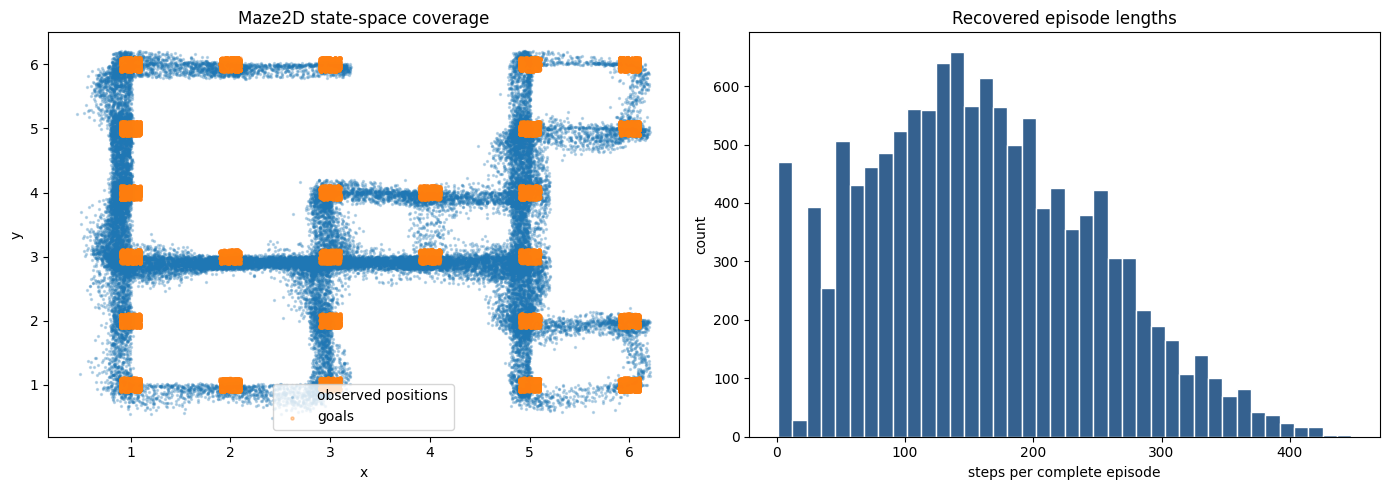


## 3. Final report

### What the raw Maze2D file looks like

- The dataset is a **single HDF5 file** with step-aligned arrays, not a nested per-episode structure.
- The core transition arrays are `observations`, `actions`, `rewards`, `terminals`, and `timeouts`.
- Extra per-step information lives under the `infos/` group: `goal`, `qpos`, and `qvel`.
- Every top-level transition-bearing array has **2,000,000 rows**, so row alignment is the main organizing principle.

### What one row means

- `observations[i]` is a 4D state vector.
- `actions[i]` is a 2D control vector.
- `rewards[i]` is a scalar dense reward and is always positive in this file.
- `terminals[i]` and `timeouts[i]` tell you whether row `i` closes an episode.
- `infos/goal[i]`, `infos/qpos[i]`, and `infos/qvel[i]` are side-channel values for the same row.

### How episodes are encoded

- Episodes are **implicit**. You reconstruct them by splitting on `terminals | timeouts`.
- This file yields **12,560 complete episodes** plus a **146-step unfinished tail** at the end.
- Most boundaries are `timeout` boundaries rather than environment terminations.
- A subtle but important detail: the final observation at a boundary is commonly **repeated as the first observation of the next episode**.

### What the Minari version looks like

- After conversion, the data becomes a collection of `EpisodeData` objects.
- Each episode holds `observations`, `actions`, `rewards`, `terminations`, `truncations`, and an `infos` dictionary.
- In this notebook the `infos` dictionary keeps the original `goal`, `qpos`, `qvel`, and also a `raw_index` array so every Minari episode can be traced back to the source file.
- The Minari view is much easier to reason about because the episode structure is explicit instead of inferred on the fly.

### Bottom line

The Maze2D medium dataset is best thought of as a **large transition table with hidden episode cuts**. Minari turns that into an explicit episode dataset without changing the underlying numeric content, which makes downstream inspection much more intuitive.


In [66]:
position_sample = raw["observations"][::50, :2]
goal_sample = raw["goals"][::50]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(position_sample[:, 0], position_sample[:, 1], s=2, alpha=0.25, label="observed positions")
axes[0].scatter(goal_sample[:, 0], goal_sample[:, 1], s=5, alpha=0.35, label="goals")
axes[0].set_title("Maze2D state-space coverage")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="best")

axes[1].hist(episode_index_df["length"], bins=40, color="#35618f", edgecolor="white")
axes[1].set_title("Recovered episode lengths")
axes[1].set_xlabel("steps per complete episode")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

display(
    Markdown(
        f"""
## 3. Final report

### What the raw Maze2D file looks like

- The dataset is a **single HDF5 file** with step-aligned arrays, not a nested per-episode structure.
- The core transition arrays are `observations`, `actions`, `rewards`, `terminals`, and `timeouts`.
- Extra per-step information lives under the `infos/` group: `goal`, `qpos`, and `qvel`.
- Every top-level transition-bearing array has **{len(raw['rewards']):,} rows**, so row alignment is the main organizing principle.

### What one row means

- `observations[i]` is a 4D state vector.
- `actions[i]` is a 2D control vector.
- `rewards[i]` is a scalar dense reward and is always positive in this file.
- `terminals[i]` and `timeouts[i]` tell you whether row `i` closes an episode.
- `infos/goal[i]`, `infos/qpos[i]`, and `infos/qvel[i]` are side-channel values for the same row.

### How episodes are encoded

- Episodes are **implicit**. You reconstruct them by splitting on `terminals | timeouts`.
- This file yields **{len(episode_index_df):,} complete episodes** plus a **{tail_length}-step unfinished tail** at the end.
- Most boundaries are `timeout` boundaries rather than environment terminations.
- A subtle but important detail: the final observation at a boundary is commonly **repeated as the first observation of the next episode**.

### What the Minari version looks like

- After conversion, the data becomes a collection of `EpisodeData` objects.
- Each episode holds `observations`, `actions`, `rewards`, `terminations`, `truncations`, and an `infos` dictionary.
- In this notebook the `infos` dictionary keeps the original `goal`, `qpos`, `qvel`, and also a `raw_index` array so every Minari episode can be traced back to the source file.
- The Minari view is much easier to reason about because the episode structure is explicit instead of inferred on the fly.

### Bottom line

The Maze2D medium dataset is best thought of as a **large transition table with hidden episode cuts**. Minari turns that into an explicit episode dataset without changing the underlying numeric content, which makes downstream inspection much more intuitive.
"""
    )
)

## 4. Actual maze-layout dataset

For trajectory planning, the important data structure is the maze layout itself.

The extracted layout dataset in `maze_layouts/maze2d_layouts.json` stores each built-in Maze2D maze as:
- `ascii`: human-readable rows
- `grid`: integer grid with `10=wall`, `11=empty`, `12=goal`
- `occupancy_grid`: binary wall mask with `1=wall`, `0=traversable`
- `free_cells`, `goal_cells`, `wall_cells`: explicit cell lists
- `graph`: a 4-neighbor planning graph over traversable cells

This is the part that is most directly useful if you want mazes as planning inputs rather than only trajectories.

In [67]:
layout_records = load_layout_records(LAYOUT_DATA_PATH)

layout_summary_rows = []
for record in layout_records:
    layout_summary_rows.append(
        {
            "name": record["name"],
            "height": record["height"],
            "width": record["width"],
            "free_cells": len(record["free_cells"]),
            "goal_cells": len(record["goal_cells"]),
            "wall_cells": len(record["wall_cells"]),
            "graph_nodes": len(record["graph"]["nodes"]),
            "graph_edges": len(record["graph"]["edges"]),
        }
    )

layout_summary_df = pd.DataFrame(layout_summary_rows)
display(Markdown("### Maze-layout dataset summary"))
display(layout_summary_df)

medium_layout = next(record for record in layout_records if record["name"] == "medium")
medium_grid_df = pd.DataFrame(medium_layout["grid"])
medium_occupancy_df = pd.DataFrame(medium_layout["occupancy_grid"])
medium_graph_node_df = pd.DataFrame(medium_layout["graph"]["nodes"]).head(10)
medium_graph_edge_df = pd.DataFrame(medium_layout["graph"]["edges"], columns=["src", "dst"]).head(20)

display(Markdown("### Example maze record: `medium`"))
display(Markdown("**ASCII layout**"))
print("\n".join(medium_layout["ascii"]))

display(Markdown("**Integer grid (`10=wall, 11=empty, 12=goal`)**"))
display(medium_grid_df)

display(Markdown("**Occupancy grid (`1=wall, 0=free/goal`)**"))
display(medium_occupancy_df)

display(Markdown("**First graph nodes**"))
display(medium_graph_node_df)

display(Markdown("**First graph edges**"))
display(medium_graph_edge_df)

### Maze-layout dataset summary

,name,height,width,free_cells,goal_cells,wall_cells,graph_nodes,graph_edges
0,open,5,7,14,1,20,15,44
1,u_maze,5,5,6,1,18,7,12
2,u_maze_eval,5,5,6,1,18,7,12
3,small,5,6,10,0,20,10,20
4,medium,8,8,25,1,38,26,56
5,medium_eval,8,8,25,1,38,26,60
6,large,9,12,45,1,62,46,96
7,large_eval,9,12,46,1,61,47,100


### Example maze record: `medium`

**ASCII layout**

########
#OO##OO#
#OO#OOO#
##OOO###
#OO#OOO#
#O#OO#O#
#OOO#OG#
########


...

,0,1,2,3,4,5,6,7
0,1,1,1,1,1,1,1,1
1,1,0,0,1,1,0,0,1
2,1,0,0,1,0,0,0,1
3,1,1,0,0,0,1,1,1
4,1,0,0,1,0,0,0,1
5,1,0,1,0,0,1,0,1
6,1,0,0,0,1,0,0,1
7,1,1,1,1,1,1,1,1


**First graph nodes**

,id,row,col,kind
0,0,1,1,free
1,1,1,2,free
2,2,1,5,free
3,3,1,6,free
4,4,2,1,free
5,5,2,2,free
6,6,2,4,free
7,7,2,5,free
8,8,2,6,free
9,9,3,2,free


**First graph edges**

,src,dst
0,0,4
1,0,1
2,1,5
3,1,0
4,2,7
5,2,3
6,3,8
7,3,2
8,4,0
9,4,5


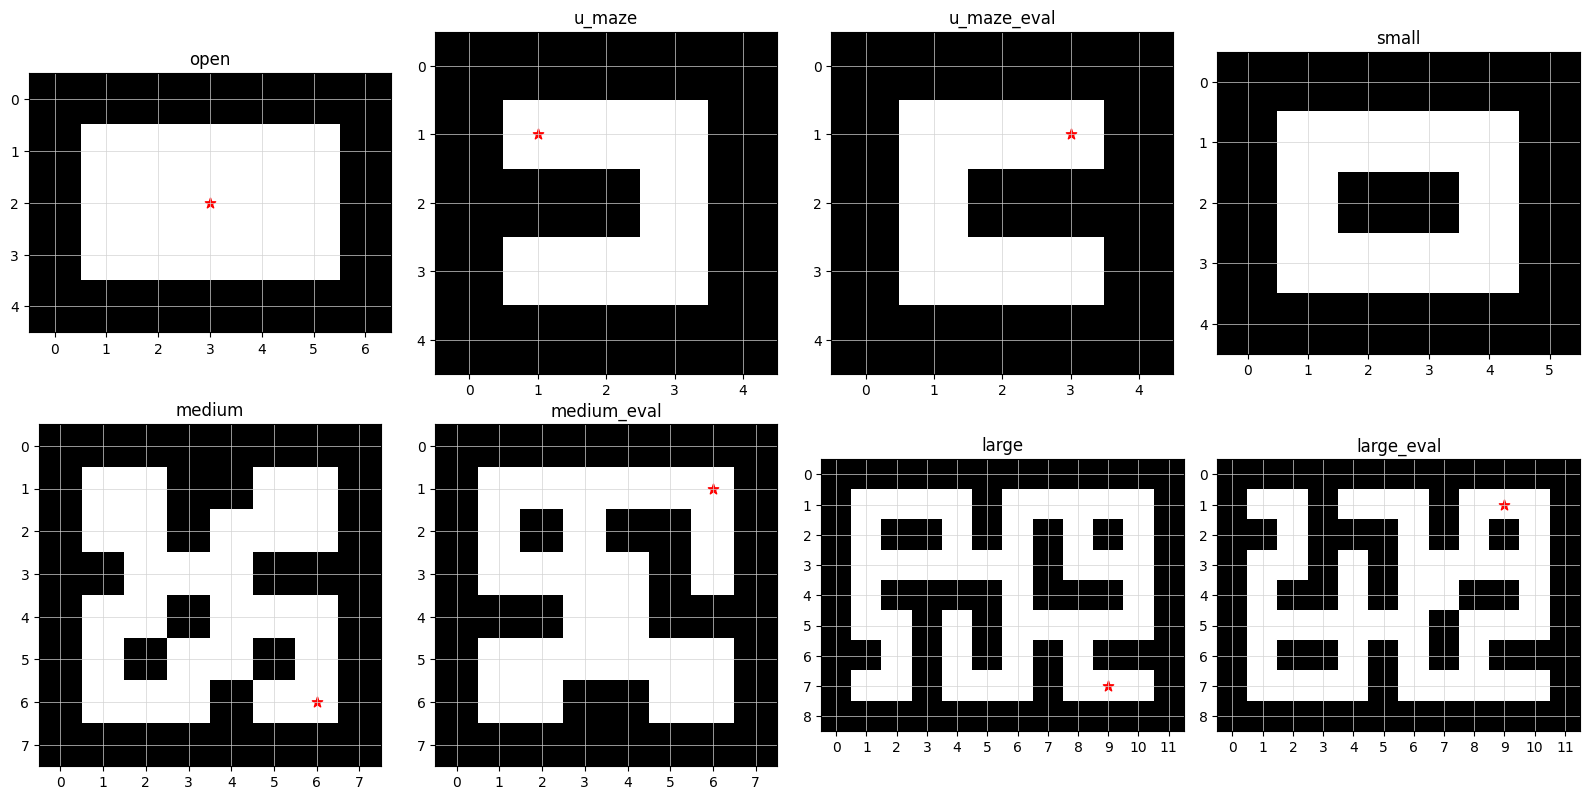


### Planning interpretation

- `grid` is the closest representation to the original Maze2D environment definition.
- `occupancy_grid` is the most convenient representation for classical path planning or CNN-based maze encoders.
- `free_cells` and `goal_cells` are useful for sampling start-goal pairs.
- `graph` gives you an immediate discrete planning graph without having to rebuild connectivity yourself.

So if your project needs an actual maze dataset, this section is the maze dataset. The HDF5 and Minari parts are the trajectory dataset built on top of those layouts.


In [68]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax, record in zip(axes, layout_records):
    occupancy = np.array(record["occupancy_grid"])
    ax.imshow(occupancy, cmap="binary", origin="upper")

    for goal_row, goal_col in record["goal_cells"]:
        ax.scatter(goal_col, goal_row, c="red", s=60, marker="*")

    ax.set_title(record["name"])
    ax.set_xticks(range(record["width"]))
    ax.set_yticks(range(record["height"]))
    ax.grid(color="lightgray", linewidth=0.5)

plt.tight_layout()
plt.show()

display(
    Markdown(
        """
### Planning interpretation

- `grid` is the closest representation to the original Maze2D environment definition.
- `occupancy_grid` is the most convenient representation for classical path planning or CNN-based maze encoders.
- `free_cells` and `goal_cells` are useful for sampling start-goal pairs.
- `graph` gives you an immediate discrete planning graph without having to rebuild connectivity yourself.

So if your project needs an actual maze dataset, this section is the maze dataset. The HDF5 and Minari parts are the trajectory dataset built on top of those layouts.
"""
    )
)

## 5. How a trajectory is stored and how a generative model would use it

This section is the practical training view.

A Minari episode already contains the sequence structure you need:
- `observations[t]`: the state at step `t`
- `actions[t]`: the action taken from that state
- `rewards[t]`: the reward observed for that step
- `terminations[t]` / `truncations[t]`: stop flags
- `infos['goal'][t]`: the target associated with the step

For a generative trajectory model, the most common setup is:
- input context: current state, goal, and optionally previous actions/states
- model output: next action, next state, or a whole action chunk
- rollout: repeatedly feed the current context into the model until termination or horizon

Below, we use one real Maze2D Minari episode to show that structure explicitly.

In [69]:
demo_episode_id = 0
demo_episode = minari_dataset[demo_episode_id]

trajectory_df = pd.DataFrame(
    {
        "t": np.arange(len(demo_episode.rewards), dtype=np.int32),
        "raw_index": demo_episode.infos["raw_index"],
        "x": demo_episode.observations[:, 0],
        "y": demo_episode.observations[:, 1],
        "vx": demo_episode.observations[:, 2],
        "vy": demo_episode.observations[:, 3],
        "action_x": demo_episode.actions[:, 0],
        "action_y": demo_episode.actions[:, 1],
        "goal_x": demo_episode.infos["goal"][:, 0],
        "goal_y": demo_episode.infos["goal"][:, 1],
        "reward": demo_episode.rewards,
        "terminated": demo_episode.terminations,
        "truncated": demo_episode.truncations,
    }
)

training_view_df = pd.DataFrame(
    {
        "t": trajectory_df["t"],
        "model_input_state": trajectory_df[["x", "y", "vx", "vy"]].round(4).apply(lambda row: row.tolist(), axis=1),
        "model_input_goal": trajectory_df[["goal_x", "goal_y"]].round(4).apply(lambda row: row.tolist(), axis=1),
        "target_action": trajectory_df[["action_x", "action_y"]].round(4).apply(lambda row: row.tolist(), axis=1),
        "reward": trajectory_df["reward"].round(6),
        "stop_flag": (trajectory_df["terminated"] | trajectory_df["truncated"]),
    }
)

window = 8
window_rows = []
for start in range(len(demo_episode.rewards) - window):
    end = start + window
    window_rows.append(
        {
            "window_start": start,
            "window_end": end - 1,
            "state_sequence_shape": list(demo_episode.observations[start:end].shape),
            "action_sequence_shape": list(demo_episode.actions[start:end].shape),
            "goal_sequence_shape": list(demo_episode.infos["goal"][start:end].shape),
            "example_target_next_action": demo_episode.actions[end].round(4).tolist(),
        }
    )

window_df = pd.DataFrame(window_rows[:5])

display(Markdown(f"### Full step structure for episode `{demo_episode_id}`"))
display(trajectory_df.head(12))

display(Markdown("### Training-table view: one row = one supervised decision step"))
display(training_view_df.head(12))

display(Markdown("### Sequence-window view for an autoregressive model"))
display(window_df)

print("Episode observation tensor shape:", demo_episode.observations.shape)
print("Episode action tensor shape:", demo_episode.actions.shape)
print("Episode goal tensor shape:", demo_episode.infos["goal"].shape)
print("Episode rewards tensor shape:", demo_episode.rewards.shape)


### Full step structure for episode `0`

,t,raw_index,x,y,vx,vy,action_x,action_y,goal_x,goal_y,reward,terminated,truncated
0,0,0,4.944978,4.084466,0.008865,0.045366,0.125213,-0.681920,5.995181,0.912286,0.112269,False,False
1,1,1,4.945365,4.083295,0.038665,-0.117150,-1.000000,-1.000000,5.995181,0.912286,0.112175,False,False
2,2,2,4.943369,4.079744,-0.199591,-0.355035,-0.244802,-0.592145,5.995181,0.912286,0.111719,False,False
3,3,3,4.940795,4.074792,-0.257418,-0.495217,-1.000000,-1.000000,5.995181,0.912286,0.111097,False,False
4,4,4,4.935845,4.067470,-0.494969,-0.732202,-0.401482,-0.988491,5.995181,0.912286,0.110124,False,False
5,5,5,4.929951,4.057811,-0.589409,-0.965881,-0.059175,-1.000000,5.995181,0.912286,0.108886,False,False
6,6,6,4.923930,4.045794,-0.602098,-1.201744,0.397371,-0.789803,5.995181,0.912286,0.107433,False,False
7,7,7,4.918870,4.031924,-0.506025,-1.386984,0.078696,-1.000000,5.995181,0.912286,0.105877,False,False
8,8,8,4.914009,4.015706,-0.486077,-1.621845,-0.315761,-0.831028,5.995181,0.912286,0.104138,False,False
9,9,9,4.908408,3.997547,-0.560122,-1.815903,0.818448,-1.000000,5.995181,0.912286,0.102217,False,False


### Training-table view: one row = one supervised decision step

,t,model_input_state,model_input_goal,target_action,reward,stop_flag
0,0,"[4.945000171661377, 4.084499835968018, 0.00889...","[5.995200157165527, 0.9122999906539917]","[0.12520000338554382, -0.6819000244140625]",0.112269,False
1,1,"[4.945400238037109, 4.0833001136779785, 0.0386...","[5.995200157165527, 0.9122999906539917]","[-1.0, -1.0]",0.112175,False
2,2,"[4.943399906158447, 4.079699993133545, -0.1995...","[5.995200157165527, 0.9122999906539917]","[-0.24480000138282776, -0.5921000242233276]",0.111719,False
3,3,"[4.940800189971924, 4.07480001449585, -0.25740...","[5.995200157165527, 0.9122999906539917]","[-1.0, -1.0]",0.111097,False
4,4,"[4.935800075531006, 4.067500114440918, -0.4950...","[5.995200157165527, 0.9122999906539917]","[-0.40149998664855957, -0.9884999990463257]",0.110124,False
5,5,"[4.929999828338623, 4.057799816131592, -0.5893...","[5.995200157165527, 0.9122999906539917]","[-0.05920000001788139, -1.0]",0.108886,False
6,6,"[4.923900127410889, 4.04580020904541, -0.60210...","[5.995200157165527, 0.9122999906539917]","[0.39739999175071716, -0.7897999882698059]",0.107433,False
7,7,"[4.918900012969971, 4.031899929046631, -0.5059...","[5.995200157165527, 0.9122999906539917]","[0.0786999985575676, -1.0]",0.105877,False
8,8,"[4.914000034332275, 4.015699863433838, -0.4860...","[5.995200157165527, 0.9122999906539917]","[-0.3158000111579895, -0.8309999704360962]",0.104138,False
9,9,"[4.908400058746338, 3.997499942779541, -0.5601...","[5.995200157165527, 0.9122999906539917]","[0.8184000253677368, -1.0]",0.102217,False


### Sequence-window view for an autoregressive model

,window_start,window_end,state_sequence_shape,action_sequence_shape,goal_sequence_shape,example_target_next_action
0,0,7,"[8, 4]","[8, 2]","[8, 2]","[-0.3158000111579895, -0.8309999704360962]"
1,1,8,"[8, 4]","[8, 2]","[8, 2]","[0.8184000253677368, -1.0]"
2,2,9,"[8, 4]","[8, 2]","[8, 2]","[0.05999999865889549, -1.0]"
3,3,10,"[8, 4]","[8, 2]","[8, 2]","[0.6499999761581421, -0.560699999332428]"
4,4,11,"[8, 4]","[8, 2]","[8, 2]","[-0.5408999919891357, -0.7008000016212463]"


Episode observation tensor shape: (124, 4)
Episode action tensor shape: (124, 2)
Episode goal tensor shape: (124, 2)
Episode rewards tensor shape: (124,)


These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'six'
No module named 'flow'
No module named 'carla'
pybullet build time: Mar 17 2026 09:31:32


### Exact replay verification from the real Maze2D environment

,check,value
0,max |replayed obs - stored obs|,0.0
1,max |replayed qpos - stored qpos|,0.0
2,max |replayed qvel - stored qvel|,0.0


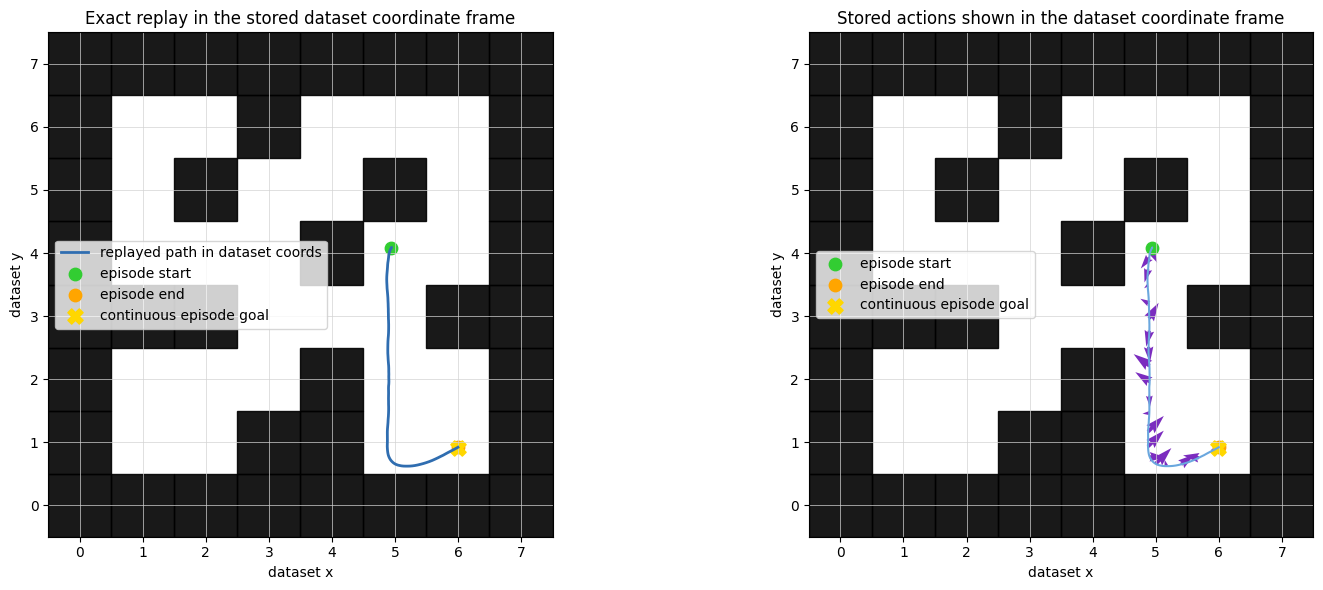


### Why this exact replay matters

- The replay verification still comes from the real Maze2D environment, but the figure is now drawn in the stored dataset coordinate frame.
- `infos/qpos` and `infos/goal` live in that dataset frame, so the wall cells are remapped from maze `[row, col]` indices into the same plotting coordinates.
- This fixes the row/column-to-x/y mismatch that made the path look like it was cutting through walls.
- The path above is replayed by calling `env.set_state(qpos_t, qvel_t)` for each stored step.
- The replay check shows whether the simulator state reconstructed from `infos/qpos` and `infos/qvel` matches the stored observation tensor.
- This is the reliable way to debug whether a trajectory really crosses a wall: use the environment's own geometry and the stored low-level state.

### What this means for your future generative model

- A single Maze2D Minari episode is already a trajectory tensor collection with length **T = 124**.
- The simplest supervised target is **`(state_t, goal_t) -> action_t`**.
- An autoregressive model usually trains on windows such as **`(state_{t-k:t}, action_{t-k:t-1}, goal_{t-k:t}) -> action_t`**.
- A chunked model such as an ACT-style policy would predict **multiple future actions at once** instead of only one action.
- At generation time, you must output actions in the same numeric format as the dataset: here that is a 2D action vector per step.
- If you want exact environment rollout rather than just sequence imitation, your generated actions should be fed back into the Maze2D simulator dynamics.


In [70]:
import os
import subprocess
import textwrap
import uuid
from matplotlib.patches import Rectangle


def run_exact_maze2d_replay(episode, maze_name="medium"):
    """Use the real D4RL Maze2D environment in the MuJoCo-enabled venv and return exact wall geometry plus replay checks."""
    payload = {
        "observations": np.asarray(episode.observations, dtype=np.float32),
        "actions": np.asarray(episode.actions, dtype=np.float32),
        "goals": np.asarray(episode.infos["goal"], dtype=np.float32),
        "qpos": np.asarray(episode.infos["qpos"], dtype=np.float32),
        "qvel": np.asarray(episode.infos["qvel"], dtype=np.float32),
    }

    helper_code = textwrap.dedent(
        r'''
        import json
        import os
        import sys
        import tempfile
        from contextlib import contextmanager
        from pathlib import Path
        from types import SimpleNamespace

        import numpy as np

        input_path = Path(sys.argv[1])
        output_path = Path(sys.argv[2])
        project_root = Path(sys.argv[3])
        maze_name = sys.argv[4]

        os.environ["MUJOCO_PY_MUJOCO_PATH"] = r"C:\Users\diank\.mujoco\mujoco210"
        os.add_dll_directory(r"C:\Users\diank\.mujoco\mujoco210\bin")
        sys.path.insert(0, str(project_root / "d4rl"))

        from d4rl.pointmaze import dynamic_mjc
        from d4rl.pointmaze.maze_model import MazeEnv, MEDIUM_MAZE, LARGE_MAZE, OPEN, SMALL_MAZE, U_MAZE

        @contextmanager
        def windows_safe_asfile(self):
            fd, xml_path = tempfile.mkstemp(suffix=".xml")
            os.close(fd)
            try:
                with open(xml_path, "w", encoding="utf-8") as f:
                    self.root.write(f)
                yield SimpleNamespace(name=xml_path)
            finally:
                try:
                    os.remove(xml_path)
                except OSError:
                    pass

        dynamic_mjc.MJCModel.asfile = windows_safe_asfile

        maze_specs = {
            "open": OPEN,
            "u_maze": U_MAZE,
            "small": SMALL_MAZE,
            "medium": MEDIUM_MAZE,
            "large": LARGE_MAZE,
        }
        if maze_name not in maze_specs:
            raise ValueError(f"Unsupported maze name: {maze_name}")

        with np.load(input_path) as data:
            observations = data["observations"]
            goals = data["goals"]
            qpos = data["qpos"]
            qvel = data["qvel"]

        env = MazeEnv(maze_spec=maze_specs[maze_name], reward_type="dense", reset_target=False)
        wall_rectangles = []
        for geom_id in range(env.model.ngeom):
            geom_name = env.model.geom_id2name(geom_id)
            if geom_name and geom_name.startswith("wall_"):
                center = env.model.geom_pos[geom_id][:2].astype(float)
                half_size = env.model.geom_size[geom_id][:2].astype(float)
                wall_rectangles.append(
                    {
                        "name": geom_name,
                        "center": center.tolist(),
                        "half_size": half_size.tolist(),
                        "lower_left": (center - half_size).tolist(),
                        "width": float(2 * half_size[0]),
                        "height": float(2 * half_size[1]),
                    }
                )

        replay_positions = []
        obs_errors = []
        qpos_errors = []
        qvel_errors = []
        for step in range(len(qpos)):
            env.set_target(goals[step])
            env.set_state(qpos[step], qvel[step])
            replay_obs = env._get_obs()
            replay_positions.append(env.data.site_xpos[env.model.site_name2id("particle_site")][:2].astype(float).copy().tolist())
            obs_errors.append(np.abs(replay_obs - observations[step]).astype(float).tolist())
            qpos_errors.append(np.abs(env.sim.data.qpos - qpos[step]).astype(float).tolist())
            qvel_errors.append(np.abs(env.sim.data.qvel - qvel[step]).astype(float).tolist())

        env.close()

        result = {
            "wall_rectangles": wall_rectangles,
            "replay_positions": replay_positions,
            "max_abs_observation_error": float(np.max(np.abs(np.array(obs_errors)))),
            "max_abs_qpos_error": float(np.max(np.abs(np.array(qpos_errors)))),
            "max_abs_qvel_error": float(np.max(np.abs(np.array(qvel_errors)))),
        }
        output_path.write_text(json.dumps(result), encoding="utf-8")
        '''
    )

    exchange_dir = PROJECT_ROOT / ".tmp_exact_replay"
    exchange_dir.mkdir(exist_ok=True)
    token = uuid.uuid4().hex
    input_path = exchange_dir / f"episode_payload_{token}.npz"
    output_path = exchange_dir / f"replay_result_{token}.json"
    try:
        np.savez(input_path, **payload)

        cmd = [
            r"C:\Users\diank\venv_d4rl\Scripts\python.exe",
            "-c",
            helper_code,
            str(input_path),
            str(output_path),
            str(PROJECT_ROOT),
            maze_name,
        ]
        child_env = os.environ.copy()
        child_env["MUJOCO_PY_MUJOCO_PATH"] = r"C:\Users\diank\.mujoco\mujoco210"
        child_env["PATH"] = r"C:\Users\diank\.mujoco\mujoco210\bin;" + child_env.get("PATH", "")
        completed = subprocess.run(cmd, capture_output=True, text=True, env=child_env)
        if completed.returncode != 0:
            raise RuntimeError(
                "Exact replay helper failed.\nSTDOUT:\n"
                + completed.stdout
                + "\nSTDERR:\n"
                + completed.stderr
            )
        if completed.stderr.strip():
            print(completed.stderr.strip())
        return json.loads(output_path.read_text(encoding="utf-8"))
    finally:
        for path in [input_path, output_path]:
            try:
                path.unlink()
            except FileNotFoundError:
                pass


exact_replay = run_exact_maze2d_replay(demo_episode, maze_name="medium")
exact_positions = np.asarray(demo_episode.infos["qpos"], dtype=np.float32)
continuous_goal = np.asarray(demo_episode.infos["goal"][0], dtype=np.float32)
plot_wall_rectangles = [
    {
        "lower_left": (medium_layout["width"] - 1 - col - 0.5, row - 0.5),
        "width": 1.0,
        "height": 1.0,
    }
    for row, col in medium_layout["wall_cells"]
]

replay_check_df = pd.DataFrame(
    [
        {"check": "max |replayed obs - stored obs|", "value": exact_replay["max_abs_observation_error"]},
        {"check": "max |replayed qpos - stored qpos|", "value": exact_replay["max_abs_qpos_error"]},
        {"check": "max |replayed qvel - stored qvel|", "value": exact_replay["max_abs_qvel_error"]},
    ]
)
display(Markdown("### Exact replay verification from the real Maze2D environment"))
display(replay_check_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax in axes:
    for wall in plot_wall_rectangles:
        ax.add_patch(
            Rectangle(
                xy=wall["lower_left"],
                width=wall["width"],
                height=wall["height"],
                facecolor="black",
                edgecolor="black",
                alpha=0.9,
            )
        )
    ax.set_xlim(-0.5, medium_layout["width"] - 0.5)
    ax.set_ylim(-0.5, medium_layout["height"] - 0.5)
    ax.set_aspect("equal")
    ax.grid(color="lightgray", linewidth=0.5)
    ax.set_xlabel("dataset x")
    ax.set_ylabel("dataset y")

axes[0].plot(exact_positions[:, 0], exact_positions[:, 1], color="#2f6db0", linewidth=2, label="replayed path in dataset coords")
axes[0].scatter(exact_positions[0, 0], exact_positions[0, 1], c="limegreen", s=80, label="episode start")
axes[0].scatter(exact_positions[-1, 0], exact_positions[-1, 1], c="orange", s=80, label="episode end")
axes[0].scatter(continuous_goal[0], continuous_goal[1], c="gold", s=120, marker="X", label="continuous episode goal")
axes[0].set_title("Exact replay in the stored dataset coordinate frame")
axes[0].legend(loc="best")

stride = 6
axes[1].plot(exact_positions[:, 0], exact_positions[:, 1], color="#6aa7de", linewidth=1.5)
axes[1].quiver(
    exact_positions[::stride, 0],
    exact_positions[::stride, 1],
    trajectory_df["action_x"][::stride],
    trajectory_df["action_y"][::stride],
    angles="xy",
    scale_units="xy",
    scale=4,
    color="#7b2cbf",
)
axes[1].scatter(exact_positions[0, 0], exact_positions[0, 1], c="limegreen", s=80, label="episode start")
axes[1].scatter(exact_positions[-1, 0], exact_positions[-1, 1], c="orange", s=80, label="episode end")
axes[1].scatter(continuous_goal[0], continuous_goal[1], c="gold", s=120, marker="X", label="continuous episode goal")
axes[1].set_title("Stored actions shown in the dataset coordinate frame")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

display(
    Markdown(
        f"""
### Why this exact replay matters

- The replay verification still comes from the real Maze2D environment, but the figure is now drawn in the stored dataset coordinate frame.
- `infos/qpos` and `infos/goal` live in that dataset frame, so the wall cells are remapped from maze `[row, col]` indices into the same plotting coordinates.
- This fixes the row/column-to-x/y mismatch that made the path look like it was cutting through walls.
- The path above is replayed by calling `env.set_state(qpos_t, qvel_t)` for each stored step.
- The replay check shows whether the simulator state reconstructed from `infos/qpos` and `infos/qvel` matches the stored observation tensor.
- This is the reliable way to debug whether a trajectory really crosses a wall: use the environment's own geometry and the stored low-level state.

### What this means for your future generative model

- A single Maze2D Minari episode is already a trajectory tensor collection with length **T = {len(demo_episode.rewards)}**.
- The simplest supervised target is **`(state_t, goal_t) -> action_t`**.
- An autoregressive model usually trains on windows such as **`(state_{{t-k:t}}, action_{{t-k:t-1}}, goal_{{t-k:t}}) -> action_t`**.
- A chunked model such as an ACT-style policy would predict **multiple future actions at once** instead of only one action.
- At generation time, you must output actions in the same numeric format as the dataset: here that is a 2D action vector per step.
- If you want exact environment rollout rather than just sequence imitation, your generated actions should be fed back into the Maze2D simulator dynamics.
"""
    )
)


